# Counting branch mutations of an `antigen-prime` epitope model's output

In [31]:
import glob
import os
import json
import pandas as pd
import numpy as np
import Bio.Phylo as bp
import matplotlib.pyplot as plt
import seaborn as sns

## Define inputs
run_path = "../data/simulated/simulated_sample_antigen"
branches_file = "../data/simulated/simulated_sample_antigen/simulated_HA_sequences.branches"
tips_file = "../data/simulated/simulated_sample_antigen/simulated_HA_sequences.tips"
tree_file = "../data/simulated/simulated_sample_antigen/simulated_HA_sequences.trees"

## Define functions for quick summary stats

In [32]:
def count_branch_mutations(filename):
    """Parse the branches file and count the number of epitope vs non-epitope mutations on main trunks and side branches.
    Parameters
    ----------
    filename : str
        The path of the branches file.

    Returns
    -------
    mutation_count_dict : dict
        A dictionary with the number of epitope and non-epitope mutations on the trunk and side-branches respectively.
    """
    num_mutations = 0
    difference = 0

    max_e = float("-inf")
    max_e_virus = ""

    max_ne = float("-inf")
    max_ne_virus = ""

    # Store visited sequences we don't double count mutations and mutation counts.
    visited = set()
    trunk_Mutations = np.array([0, 0])
    branch_Mutations = np.array([0, 0])

    # Each line is a sampled virus.
    with open(filename) as f:
        lines = f.readlines()

    counts_dict = {}
    for line in lines:
        elements = line.split(",")

        child = elements[0].split('"')[1]
        v_isTrunk = elements[2]
        v_eMutations = int(elements[10].strip())
        v_neMutations = int(elements[11].split("}")[0].strip())

        parent = elements[11].split('"')[1]
        vp_isTrunk = elements[13]
        vp_eMutations = int(elements[21].strip())
        vp_neMutations = int(elements[22].split("}")[0].strip())

        v_sequence = elements[7]
        vp_sequence = elements[18]

        if v_sequence != vp_sequence:
            num_mutations += 1  # change to hamming distance

        key = (vp_isTrunk, v_isTrunk)

        if key not in counts_dict:
            counts_dict[key] = 1
        else:
            counts_dict[key] += 1

        v_Mutations = np.array([v_eMutations, v_neMutations])
        vp_Mutations = np.array([vp_eMutations, vp_neMutations])
        diff = v_Mutations - vp_Mutations
        if (diff[0] + diff[1]) > 1:
            difference = difference + diff[0] + diff[1] - 1

        # print(vp_Mutations, v_Mutations)
        if key == ("1", "1"):
            if v_eMutations > max_e:
                max_e = v_eMutations
                max_e_virus = child
            if v_neMutations > max_ne:
                max_ne = v_neMutations
                max_ne_virus = child

            trunk_Mutations += diff
        else:
            branch_Mutations += diff
        visited.add(parent)

    print(
        "number of double counted epitope and/or non-epitope mutations:\n", difference
    )
    mutation_count_dict = {
        "side_branch_epitope_mutations": int(branch_Mutations[0]),
        "side_branch_non-epitope_mutations": int(branch_Mutations[1]),
        "side_branch_epitope_to_non-epitope_ratio": (
            float(branch_Mutations[0] / branch_Mutations[1])
        ),
        "trunk_epitope_mutations": int(trunk_Mutations[0]),
        "trunk_non-epitope_mutations": int(trunk_Mutations[1]),
        "trunk_epitope_to_non-epitope_ratio": float(
            trunk_Mutations[0] / trunk_Mutations[1]
        ),
    }

    return mutation_count_dict

In [33]:
def calculate_antigenic_movement_per_year(
    tips_df, date_col="year", phenotype_cols=["ag1", "ag2"]
):
    """Calculate antigenic movement per year

    Args:
        tips_df (pd.DataFrame): A date-sorted dataframe of tips
        date_col (str, optional): The column name of the date. Defaults to "year".
        phenotype_cols (list, optional): The column names of the antigenic coordinates. Defaults to ["ag1", "ag2"].
    Return:
        antigenic_movement (float): average antigenic movement per year
    """
    # Just grab first and last virus sample and simulation duration
    tips_df = tips_df.sort_values(by=[date_col]).reset_index(drop=True)
    n_years = tips_df[date_col].max()
    first_virus = tips_df.iloc[0]
    last_virus = tips_df.iloc[-1]

    # Calculate antigenic movement over sim
    dist = np.linalg.norm(first_virus[phenotype_cols] - last_virus[phenotype_cols])
    antigenic_movement = dist / n_years

    return antigenic_movement

In [34]:
def calculate_case_counts_over_time(cases):
    """
    Calculate the number of cases per 100k people for a dataframe of cases.

    Args:
        cases (pd.DataFrame): dataframe of cases
    Return:
        cases (pd.DataFrame): A copy of the dataframe with new columns for total and reginol case counts per 100k
    """
    cases["total_cases_per_100k"] = cases["totalCases"] / 100000
    cases["north_cases_per_100k"] = cases["northCases"] / 100000
    cases["tropics_cases_per_100k"] = cases["tropicsCases"] / 100000
    cases["south_cases_per_100k"] = cases["southCases"] / 100000

    return cases

In [35]:
def calculate_attack_rate(cases):
    """Calculate the attack rate for a dataframe of cases.

    Attack rate is defined as the number of infected individuals divided by the number of susceptible individuals.

    Args:
        cases (pd.DataFrame): dataframe of cases
    Return:
        cases (pd.DataFrame): A copy of the dataframe with new columns for total and reginol attack rates
    """
    cases["total_attack_rate"] = cases["totalI"] / cases["totalS"]
    cases["north_attack_rate"] = cases["northI"] / cases["northS"]
    cases["tropics_attack_rate"] = cases["tropicsI"] / cases["tropicsS"]
    cases["south_attack_rate"] = cases["southI"] / cases["southS"]

    return cases


In [36]:
def calculate_case_counts_over_time(cases):
    """
    Calculate the number of cases per 100k people for a dataframe of cases.

    Args:
        cases (pd.DataFrame): dataframe of cases
    Return:
        cases (pd.DataFrame): A copy of the dataframe with new columns for total and reginol case counts per 100k
    """
    cases["total_cases_per_100k"] = cases["totalCases"] / 100000
    cases["north_cases_per_100k"] = cases["northCases"] / 100000
    cases["tropics_cases_per_100k"] = cases["tropicsCases"] / 100000
    cases["south_cases_per_100k"] = cases["southCases"] / 100000

    return cases

In [37]:
def read_run(path):
    """Read in a run and return datafiles for cases, a newick tree, and sampled tips.

    Args:
        path (str): path to run directory
    Return:
        cases_df (pd.DataFrame): dataframe of cases
        tree (BioPhylo.Tree): tree object
        tips (pd.DataFrame): dataframe of tips
    """
    cases = pd.read_csv(f"{path}/out_timeseries.csv")
    tree = bp.read(f"{path}/simulated_HA_sequences.trees", "newick")
    tips = pd.read_csv(f"{path}/simulated_HA_sequences.tips")
    cases["path"] = path
    tips["path"] = path

    # Add custom columns for cases.
    cases = calculate_case_counts_over_time(cases)
    cases = calculate_attack_rate(cases)

    return cases, tree, tips


## Generate tree of viruses

In [38]:
cases, tree, tips = read_run(run_path)

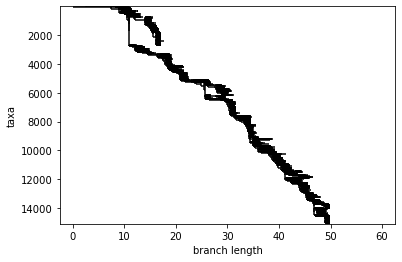

In [39]:
bp.draw(tree, lambda node: None)

Text(0.5, 0, 'antigenic coordinate 2')

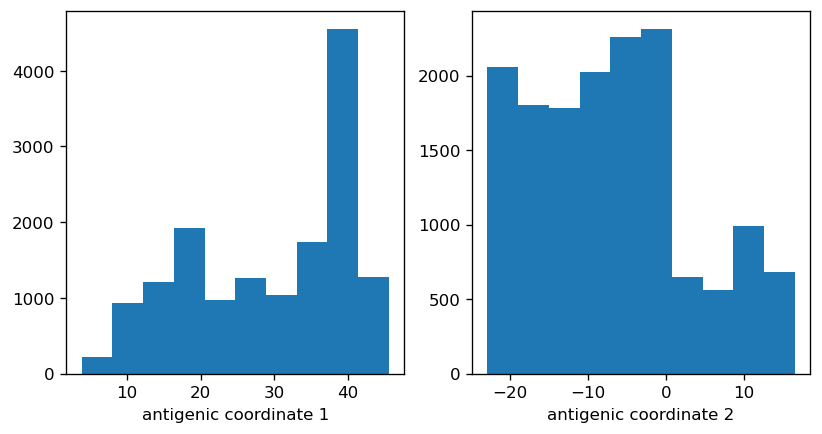

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=120)
axes[0].hist(tips['ag1'])
axes[0].set_xlabel("antigenic coordinate 1")
axes[1].hist(tips['ag2'])
axes[1].set_xlabel("antigenic coordinate 2")

## Table 7 from John's paper. 
These values are for natural populations, and we want to replicate them with our `antigen-prime` simulations.

| branch type      | epitope mutations | non-epitope mutations | epitope-to-non-epitope ratio      |
| :---             |    :----:         |          :----:       |              :----:               |
| side branch      |     485           |            1177       |              0.41                 |
| trunk            |      50           |             32        |              1.56                 |

In [41]:
mut_count_dict = count_branch_mutations(branches_file)

number of double counted epitope and/or non-epitope mutations:
 63


In [42]:
mut_count_dict

{'side_branch_epitope_mutations': 540,
 'side_branch_non-epitope_mutations': 3142,
 'side_branch_epitope_to_non-epitope_ratio': 0.1718650541056652,
 'trunk_epitope_mutations': 78,
 'trunk_non-epitope_mutations': 123,
 'trunk_epitope_to_non-epitope_ratio': 0.6341463414634146}